# Cv folds analysis

First of all, I'm interested in how fold 1 differs from others. Why is it scored worse? What can be done to improve the metric?

## Imports

In [36]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

from heart_failure.dataset import split_data
from heart_failure.modeling.models import build_dt_pipeline
from heart_failure.config.modeling import CV_SPLITS
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, CHEST_PAIN_TYPE, ST_SLOPE, MODELS_DIR
from heart_failure.config.train import RANDOM_STATE
from heart_failure.utils import cat_pct_distr_by_group
from heart_failure.features import get_fe_pipeline

In [65]:
FOLD = "fold"
Y_PROBA = "y_proba"

In [29]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)
df_train = X_train.merge(y_train, left_index=True, right_index=True)

In [40]:
with open(MODELS_DIR / "dt_model.pkl", "rb") as f:
    model = pickle.load(f)

## Exploration

In [31]:
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
df_train[FOLD] = -1

for fold, (_, test_idx) in enumerate(cv.split(X_train, y_train)):
    df_train.iloc[test_idx, df_train.columns.get_loc(FOLD)] = fold

In [32]:
df_train.select_dtypes(include="number").groupby(FOLD).agg(["mean", "median"])

Age          RestingBP        Cholesterol        FastingBS  \
            mean median        mean median        mean median      mean   
split                                                                     
0      54.162791   55.0  134.108527  130.0  242.062016  233.0  0.224806   
1      53.891473   55.0  133.139535  130.0  238.081395  233.0  0.232558   
2      52.968992   55.0  134.612403  132.0  243.616279  237.0  0.201550   
3      53.860465   54.0  131.472868  130.0  249.360465  236.0  0.271318   
4      53.155039   54.0  132.054264  130.0  242.655039  236.0  0.286822   

                   MaxHR          Oldpeak        HeartDisease         
      median        mean median      mean median         mean median  
split                                                                 
0        0.0  136.736434  135.0  0.968992    0.8     0.550388    1.0  
1        0.0  136.744186  140.0  0.882171    0.4     0.550388    1.0  
2        0.0  138.341085  137.0  0.891473    0.6     0.550388    1.0  
3        0.0  138.945736  142.0  0.882171    0.5     0.550388    1.0  
4        0.0  133.403101  133.0  0.690698    0.2     0.558140    1.0

- Mean (or median) Age, RestingBP, Cholesterol, MaxHR in all groups are almost equal.
- FastingBS in folds 3, 4 is on average more than the rest.
- Oldpeak in fold 0 is more, and in fold 4 is less than the rest.

Accordingly, it’s not a matter of continuous features.

In [15]:
cat_pct_distr_by_group(df_train, df_train[FOLD])

Sex           ChestPainType                                \
              F         M           ASY       ATA       NAP        TA   
split                                                                   
0      0.201550  0.798450      0.519380  0.217054  0.193798  0.069767   
1      0.217054  0.782946      0.480620  0.170543  0.248062  0.100775   
2      0.186047  0.813953      0.542636  0.186047  0.240310  0.031008   
3      0.263566  0.736434      0.496124  0.178295  0.271318  0.054264   
4      0.186047  0.813953      0.581395  0.209302  0.201550  0.007752   

      RestingECG                     ExerciseAngina            ST_Slope  \
             LVH    Normal        ST              N         Y      Down   
split                                                                     
0       0.217054  0.565891  0.217054       0.612403  0.387597  0.046512   
1       0.186047  0.581395  0.232558       0.573643  0.426357  0.093023   
2       0.224806  0.581395  0.193798       0.596899  0.403101  0.046512   
3       0.217054  0.643411  0.139535       0.620155  0.379845  0.069767   
4       0.139535  0.658915  0.201550       0.612403  0.387597  0.054264   

                           
           Flat        Up  
split                      
0      0.534884  0.418605  
1      0.488372  0.418605  
2      0.503876  0.449612  
3      0.488372  0.441860  
4      0.503876  0.441860

- Fold 3 has a slightly higher percentage of women than the others.
- FOld 1 has a higher percentage of ChestPainType TA than the others.
- In fold 1, ST_Slope Down occurs more often than in the others

Since fold 1 is quite similar to fold 0, and fold 0 does not have any peculiarities (the average feature is larger/smaller than usual), it is either a difference in the distributions of the ChestPainType and ST_Slope features, or there are many too uncertain cases for the model (50/50).

In [22]:
df_train.groupby([FOLD, CHEST_PAIN_TYPE])[HEART_DISEASE].mean().unstack()

ChestPainType,ASY,ATA,NAP,TA
split,,,,
0,0.776119,0.071429,0.480000,0.555556
1,0.854839,0.090909,0.375000,0.307692
2,0.814286,0.333333,0.161290,0.250000
3,0.781250,0.043478,0.485714,0.428571
4,0.760000,0.148148,0.384615,1.000000


Here the TA changes a lot between splits. But I don't think that's the case.

In [23]:
df_train.groupby([FOLD, ST_SLOPE])[HEART_DISEASE].mean().unstack()

ST_Slope,Down,Flat,Up
split,,,
0,0.666667,0.811594,0.203704
1,0.750000,0.825397,0.185185
2,0.833333,0.815385,0.224138
3,0.888889,0.857143,0.157895
4,0.857143,0.892308,0.140351


There are no particular differences between the folds.

It is still unclear where the worst score comes from. Therefore, it is worth looking at the PR-curve graphs for each fold. As a model, I will take a decision tree.

In [ ]:
fe_pipeline = get_fe_pipeline(combine_rules=False)
base_model = build_dt_pipeline(fe_pipeline)
base_model.set_params(**model.get_params())

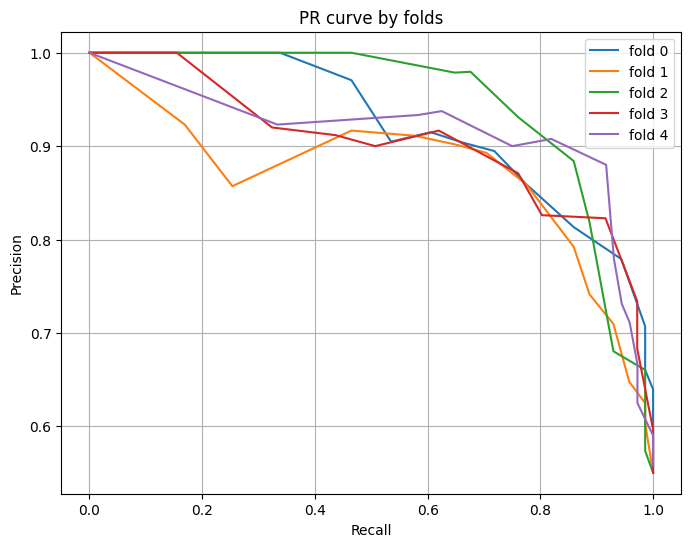

In [77]:
plt.figure(figsize=(8, 6))
df_train[Y_PROBA] = -1.

for fold, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_v = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[test_idx]

    model_ = clone(base_model)
    model_.fit(X_tr, y_tr)

    y_proba = model_.predict_proba(X_v)[:, 1]
    df_train.iloc[test_idx, df_train.columns.get_loc(Y_PROBA)] = y_proba
    precision, recall, _ = precision_recall_curve(y_v, y_proba)
    plt.plot(recall, precision, label=f"fold {fold}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR curve by folds")
plt.legend()
plt.grid()
plt.show()

Given that the PR-AUC on this fold is similar from model to model, this is not something specific to the tree. There are probably some objects in this fold that look like positive class (high proba) but are null class.

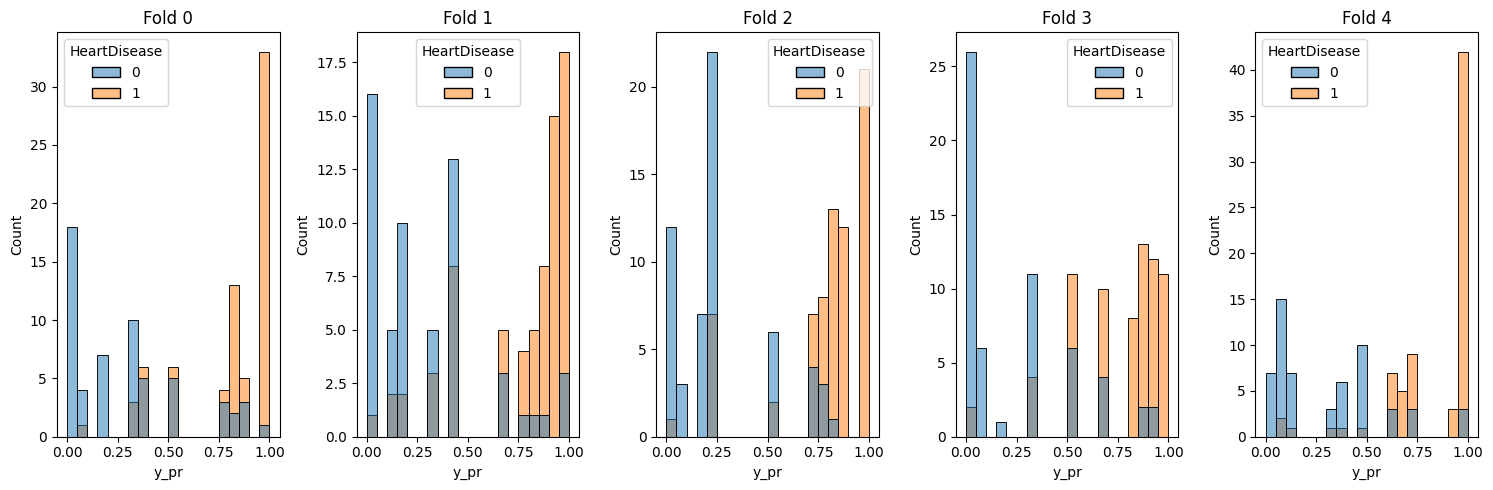

In [64]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i in range(5):
    fold = df_train[df_train[FOLD] == i]
    sns.histplot(fold, x=Y_PROBA, hue=HEART_DISEASE, ax=axes[i], bins=20)
    axes[i].set_title(f"Fold {i}")

plt.tight_layout()
plt.show()

In fold 1, as in fold 4, there are cases when actual 0 has a probability of being class 1 of almost 1. However, in fold 1, the ratio of actual 1 to actual 0 with such a chance is much less than that of fold 4. Because of this, PR-AUC is lower. There are also quite a few class-1 objects that are more likely to belong to class 0. It remains only to understand where these cases come from.

I want to consider those actual 0s which y_proba >= 0.95.

In [76]:
df_train[(df_train[Y_PROBA] >= 0.95) & (df_train[HEART_DISEASE] == 0) & (df_train[FOLD] == 1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,split,y_proba
632,64,M,TA,110.0,211.0,0,LVH,144,Y,1.8,Flat,0,1,0.966667
26,53,M,ASY,124.0,260.0,0,ST,112,Y,3.0,Flat,0,1,1.000000
555,75,M,ASY,160.0,310.0,1,Normal,112,Y,2.0,Down,0,1,0.966667


In these examples, almost all features indicate the presence of a disease. I won’t be able to adapt to them (and shouldn’t). This fold is not “wrong”, it just accounted for more such confident FPs. Because of this, the PR-AUC is lower.

Now let's look at the opposite cases.

In [78]:
df_train[(df_train[Y_PROBA] <= 0.05) & (df_train[HEART_DISEASE] == 1) & (df_train[FOLD] == 1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,split,y_proba
683,47,M,NAP,108.0,243.0,0,Normal,152,N,0.0,Up,1,1,0.0


Here we can see the combination of Oldpeak=0 and ST_Slope=Up, while Cholesterol is higher than normal. The problem is that there are too few such cases for the model not to regularize for this (too few samples get into the leaf). But if I remove this limitation, then overfitting for other combinations of features may occur. As an option, add the Oldpeak_ST_Slope_Cholesterol_te feature instead of the Oldpeak_ST_Slope_te.

In [79]:
df_train[(df_train[Y_PROBA] <= 0.05) & (df_train[HEART_DISEASE] == 1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,split,y_proba
616,57,M,ATA,124.0,261.0,0,Normal,141,N,0.3,Up,1,2,0.000000
683,47,M,NAP,108.0,243.0,0,Normal,152,N,0.0,Up,1,1,0.000000
330,60,M,NAP,115.0,233.0,1,Normal,143,N,2.4,Up,1,3,0.025641
651,59,M,TA,160.0,273.0,0,LVH,125,N,0.0,Up,1,3,0.025641


In addition to fold 1, there are 2 more similar cases on other folds. The feature makes sense to be there.